# Logistic Regression Source-Zone Workflow v1

Clean notebook for the interpretable logistic-regression source-zone model. It uses the modular repo pipeline instead of rebuilding rasters manually in the notebook.

Main idea: train a classifier to predict the binary source-zone label from configured terrain, soil, burn, vegetation-change, and hydrologic features. The final held-out test area is polygon `4`; polygon `3` is the training area.

## 1. Setup

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Find repo root whether the notebook is run from repo root or notebooks/.
REPO = Path.cwd().resolve()
for candidate in [REPO, *REPO.parents]:
    if (candidate / "src" / "pci_source_zones").exists():
        REPO = candidate
        break

if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))

from pci_source_zones.config import load_config
from pci_source_zones.inputs import read_raster
from pci_source_zones.ml.dataset import build_ml_dataset
from pci_source_zones.ml.workflow import run_ml_workflow
from pci_source_zones.ml.tuning import run_tuning_workflow

print("repo:", REPO)


repo: /home/abdullah/pci-source-zones


## 2. Config

In [2]:

CONFIG = REPO / "config" / "ml_logistic_regression.yaml"
cfg = load_config(CONFIG)

print("config:", CONFIG)
print("model:", cfg["ml"]["model"]["type"])
print("target:", cfg["ml"]["target"])
print("split:", cfg["ml"]["split"]["method"])
print("features numeric:", cfg["ml"]["features"]["numeric"])
print("features categorical:", cfg["ml"]["features"]["categorical"])


config: /home/abdullah/pci-source-zones/config/ml_logistic_regression.yaml
model: logistic_regression
target: {'type': 'physics_dod', 'c_min': 5, 'c_channel': 120, 'erosion_threshold_m': -0.55, 'exclude_channels_from_training': True, 'export': True, 'nodata': 255}
split: polygons
features numeric: ['slope', 'drainage_area', 'soil_thickness', 'soil_density', 'sand_total', 'silt_total', 'clay_total', 'porosity', 'field_capacity', 'saturated_water_content', 'soil_transmissivity', 'saturated_hydraulic_conductivity', 'et_diff', 'ndvi_diff']
features categorical: ['burn_severity', 'soil_texture', 'landcover']


## 3. Inspect Dataset And Splits

In [3]:
def split_summary_table(data):
    rows = []
    for split, idx in data.splits.items():
        yy = data.y[idx]
        rows.append({
            "split": split,
            "cells": len(idx),
            "positive": int((yy == 1).sum()),
            "negative": int((yy == 0).sum()),
            "positive_fraction": float((yy == 1).mean()) if len(yy) else np.nan,
        })
    return pd.DataFrame(rows)


def metrics_table(metrics):
    rows = []
    for split, vals in metrics.items():
        row = {"split": split}
        for key in ["n", "positive", "negative", "accuracy", "balanced_accuracy", "mcc", "precision", "recall", "f1", "roc_auc"]:
            if key in vals:
                row[key] = vals[key]
        rows.append(row)
    return pd.DataFrame(rows)


def plot_three_maps(target_path, probability_path, class_path, title):
    target, _ = read_raster(target_path)
    prob, _ = read_raster(probability_path)
    klass, _ = read_raster(class_path)

    klass_plot = np.where(klass == 255, np.nan, klass)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(np.where(target == 255, np.nan, target), cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Target")

    im = axes[1].imshow(prob, cmap="viridis", vmin=0, vmax=1)
    axes[1].set_title("Predicted probability")
    plt.colorbar(im, ax=axes[1], fraction=0.046)

    axes[2].imshow(klass_plot, cmap="gray", vmin=0, vmax=1)
    axes[2].set_title("Binary class")

    for ax in axes:
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


data = build_ml_dataset(cfg)

print("target rule:", data.target_data.positive_rule)
print("X shape:", data.X.shape)
print("features:", list(data.X.columns))
display(split_summary_table(data))


target rule: 5 <= G < 120 and DoD < -0.55
X shape: (473933, 17)
features: ['slope', 'drainage_area', 'soil_thickness', 'soil_density', 'sand_total', 'silt_total', 'clay_total', 'porosity', 'field_capacity', 'saturated_water_content', 'soil_transmissivity', 'saturated_hydraulic_conductivity', 'et_diff', 'ndvi_diff', 'burn_severity', 'soil_texture', 'landcover']


,split,cells,positive,negative,positive_fraction
0,train,42968,10742,32226,0.250000
1,test,30233,2347,27886,0.077630
2,val,7350,1194,6156,0.162449


## 4. Train Logistic Regression And Export Products

In [4]:

result = run_ml_workflow(cfg, model_name="logistic_regression")

for key, value in result.items():
    print(f"{key}: {value}")


model_name: logistic_regression
output_dir: /mnt/c/Users/amehedi/Downloads/source_area_workflow/ml/logistic_regression
target: /mnt/c/Users/amehedi/Downloads/source_area_workflow/ml/logistic_regression/ml_target.tif
probability: /mnt/c/Users/amehedi/Downloads/source_area_workflow/ml/logistic_regression/logistic_regression_source_probability.tif
class: /mnt/c/Users/amehedi/Downloads/source_area_workflow/ml/logistic_regression/logistic_regression_source_class_p0p5.tif
model: /mnt/c/Users/amehedi/Downloads/source_area_workflow/ml/logistic_regression/logistic_regression_model.joblib
metrics: /mnt/c/Users/amehedi/Downloads/source_area_workflow/ml/logistic_regression/logistic_regression_metrics.json
feature_scores: /mnt/c/Users/amehedi/Downloads/source_area_workflow/ml/logistic_regression/logistic_regression_feature_scores.csv
split_summary: /mnt/c/Users/amehedi/Downloads/source_area_workflow/ml/logistic_regression/split_summary.csv
feature_names: ['slope', 'drainage_area', 'soil_thickness',

## 5. Metrics

In [5]:

metrics = json.loads(Path(result["metrics"]).read_text())
display(metrics_table(metrics))

for split, vals in metrics.items():
    print("\n", split, "confusion matrix [0,1] rows/cols")
    print(np.array(vals["confusion_matrix"]))


,split,n,positive,negative,accuracy,balanced_accuracy,mcc,precision,recall,f1,roc_auc
0,train,42968,10742,32226,0.597235,0.608360,0.188068,0.336814,0.630609,0.439100,0.651142
1,test,30233,2347,27886,0.325770,0.588076,0.106949,0.094765,0.898594,0.171449,0.591039
2,val,7350,1194,6156,0.591973,0.607899,0.159978,0.227588,0.631491,0.334591,0.647833



 train confusion matrix [0,1] rows/cols
[[18888 13338]
 [ 3968  6774]]

 test confusion matrix [0,1] rows/cols
[[ 7740 20146]
 [  238  2109]]

 val confusion matrix [0,1] rows/cols
[[3597 2559]
 [ 440  754]]


## 6. Coefficients

,feature,coefficient
0,burn_severity_0.0,-2.969607
1,landcover_42.0,1.341333
2,burn_severity_4.0,1.296831
3,landcover_71.0,-1.163334
4,burn_severity_3.0,1.084839
5,soil_transmissivity,1.036014
6,soil_thickness,-0.965344
7,burn_severity_2.0,0.724642
8,landcover_52.0,-0.492587
9,burn_severity_1.0,-0.398188


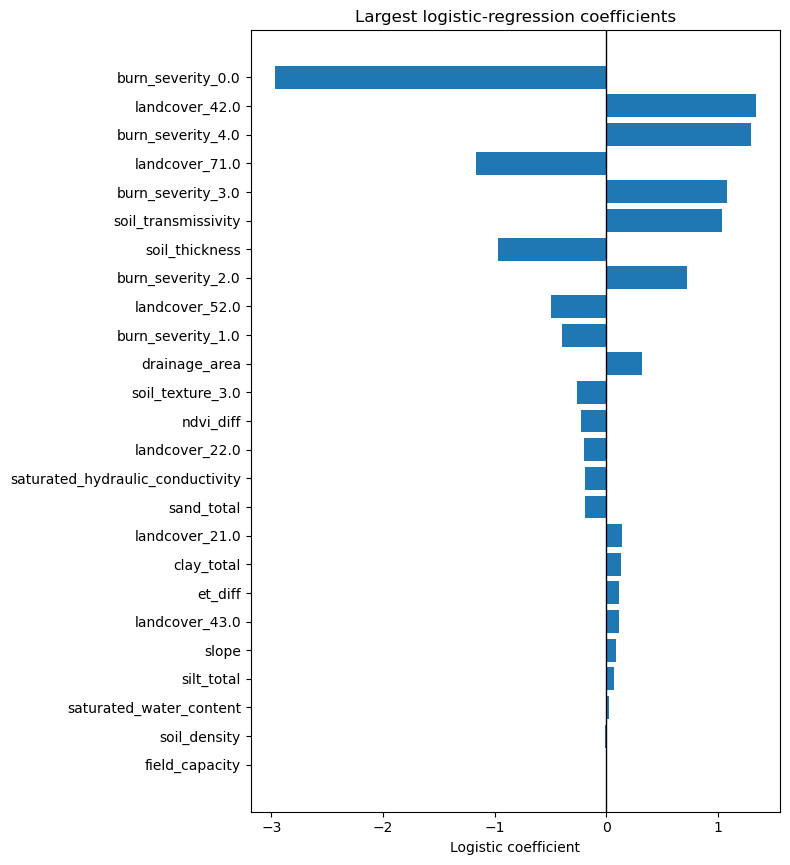

In [6]:

coef = pd.read_csv(result["feature_scores"])
display(coef.head(25))

plot_df = coef.copy()
plot_df["abs_coefficient"] = plot_df["coefficient"].abs()
plot_df = plot_df.sort_values("abs_coefficient", ascending=True).tail(25)

plt.figure(figsize=(8, max(4, 0.35 * len(plot_df))))
plt.barh(plot_df["feature"], plot_df["coefficient"])
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Logistic coefficient")
plt.title("Largest logistic-regression coefficients")
plt.tight_layout()
plt.show()


## 7. Output Maps

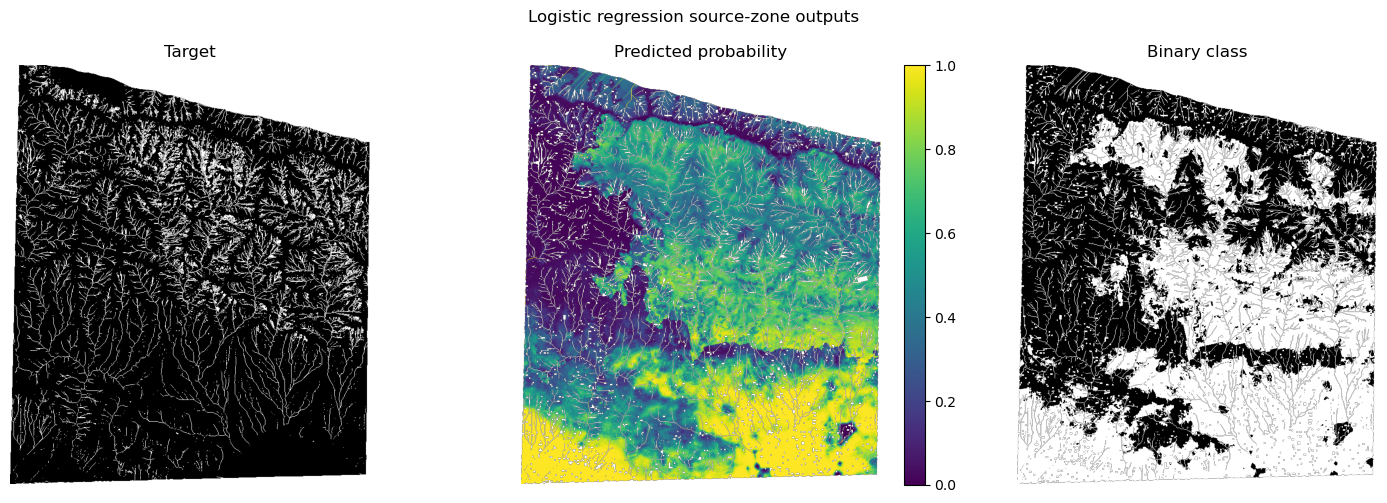

In [7]:

plot_three_maps(
    result["target"],
    result["probability"],
    result["class"],
    "Logistic regression source-zone outputs",
)


## 8. Optional C-Equivalent View

This is only an interpretation helper. It maps ML probability to an equivalent percentile of the sampled `C` distribution if `c_samples.csv` exists. It is not a directly observed physical C.

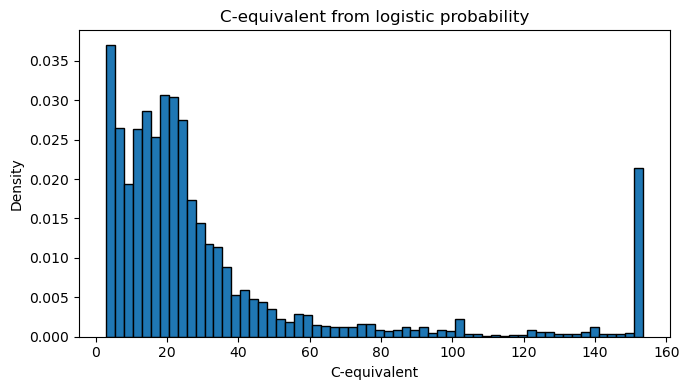

In [8]:

C_SAMPLES = Path("/mnt/c/Users/amehedi/Downloads/source_area_workflow/c_samples.csv")

if C_SAMPLES.exists():
    c_values = pd.read_csv(C_SAMPLES)["C"].dropna().to_numpy()
    c_values = np.sort(c_values[np.isfinite(c_values)])

    prob, profile = read_raster(result["probability"])
    p = np.clip(prob, 0.001, 0.999)
    q = (np.arange(1, len(c_values) + 1) - 0.5) / len(c_values)
    c_equiv = np.interp(p, q, c_values)
    c_equiv[~np.isfinite(prob)] = np.nan

    vals = c_equiv[np.isfinite(c_equiv)]
    plt.figure(figsize=(7, 4))
    plt.hist(vals, bins=60, density=True, edgecolor="black")
    plt.xlabel("C-equivalent")
    plt.ylabel("Density")
    plt.title("C-equivalent from logistic probability")
    plt.tight_layout()
    plt.show()
else:
    print("Missing C samples:", C_SAMPLES)
